# JIGA IA-CD
## Módulo 5
## Atividade 3 - Busca e Otimização

## EQUIPE PCPE


#Time Docente
**Professor-Apoiador**: Dr. Diego Marconi Pinheiro Ferreira Silva

**Pós-Graduando-Apoiador**: Júlio Taveira 


In [ ]:
!python -m pip install tsplib95 networkx matplotlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.1 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.0
    Uninstalling networkx-3.0:
      Successfully uninstalled networkx-3.0


# Classes Bases

1. Qual o papel de `child.path_cost` na função `best_first_search` ?

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
import numpy as np
from queue import PriorityQueue
import networkx as nx
import tsplib95

@dataclass
class State:
  
  def __eq__(self, other):
   pass

  def __hash__(self):
    pass

  def __str__(self) -> str:
      pass

@dataclass
class Node:
    state: State
    parent: Node
    action: Node
    path_cost: float

    def __lt__(self, other):
        return self.path_cost < other.path_cost

    def __str__(self) -> str:
      return str(self.state) + "\n\n" + str(self.parent)


@dataclass()
class Problem:
    initial_node: Node

    def result(self, state: State, action: State):
      return action

    def action_cost(self, source: State, action: Node, target: State):
      pass

    def actions(self, state : Node):
      pass
  
    def is_goal(self, current_state: State):
      pass
      

def expand(problem: Problem, node: Node):
  source = node.state
  for action in problem.actions(source):
    target = problem.result(source, action)
   # if problem.action_cost(source, action, target) is None:
   #   cost = node.path_cost
    #else:
    cost = node.path_cost + problem.action_cost(source, action, target)
    next_node = Node(state=target, parent=node, action=action, path_cost=cost)
    yield next_node

def best_first_search(problem : Problem):
  frontier = PriorityQueue()
  initial_state = problem.initial_node
  reached = dict()
  frontier.put((initial_state.path_cost, initial_state))
  while not frontier.empty():
    node = frontier.get()[1]
    if problem.is_goal(node.state):
      return node
    for child in expand(problem, node):
      s = child.state
      if s not in reached or child.path_cost < reached[s].path_cost:
        reached[s] = child
        """1. Qual o papel de `child.path_cost` na função `best_first_search` ?"""
        frontier.put((child.path_cost, child))
  return None



# 1. Problema da Romênia

## 1.1 Implementação

1. Implemente a verificação de igualdade entre estados em `def __eq__(self, other)` 
2. Implemente o cáculo do custo em `def action_cost(self, source: State, action: Node, target: State)`
3. Implemente a geração de ações em `def actions(self, state : Node)`
4. Implemente a verificação do estado final em `def is_goal(self, current_state: State)`

In [ ]:
from dataclasses import dataclass
import numpy as np
import networkx as nx

@dataclass
class RomaniaState(State):
    visited_nodes: list
    unvisited_nodes: list

    def __eq__(self, other):
        if not isinstance(other, State):
            return NotImplemented
        """1. Implemente a verificação de igualdade entre estados em `def __eq__(self, other)"""
        return self.visited_nodes == other.visited_nodes
                
    def __hash__(self):
        return hash(str(self.visited_nodes))

    def __str__(self) -> str:
        return str(self.visited_nodes)


@dataclass
class RomaniaProblem(Problem):
    graph: nx.Graph

    def action_cost(self, source: State, action: Node, target: State):
      cost = 0
      if len(source.visited_nodes) > 0:
        cost = float("inf")
        source_last_id = source.visited_nodes[-1]
        target_last_id = target.visited_nodes[-1]
        if self.graph.has_edge(source_last_id, target_last_id):
          """2. Implemente o cáculo do custo em `def action_cost(self, source: State, action: Node, target: State)"""
          cost = self.graph.get_edge_data(source_last_id, target_last_id)['weight']
      return cost

    def actions(self, state : Node):
      """3. Implemente a geração de ações em `def actions(self, state : Node)`"""
      for node_id in state.unvisited_nodes:
          unvisited_nodes = list(state.unvisited_nodes)
          unvisited_nodes.remove(node_id)
          next_node = RomaniaState(visited_nodes=state.visited_nodes + [node_id], unvisited_nodes=unvisited_nodes)
          yield next_node
  
    def is_goal(self, current_state: State):
        """4. Implemente a verificação do estado final em `def is_goal(self, current_state: State)`"""
        return current_state.visited_nodes[-1] == 'Bucharest'



## 1.2 Construção do Grafo

1. Construa o grafo inteiro

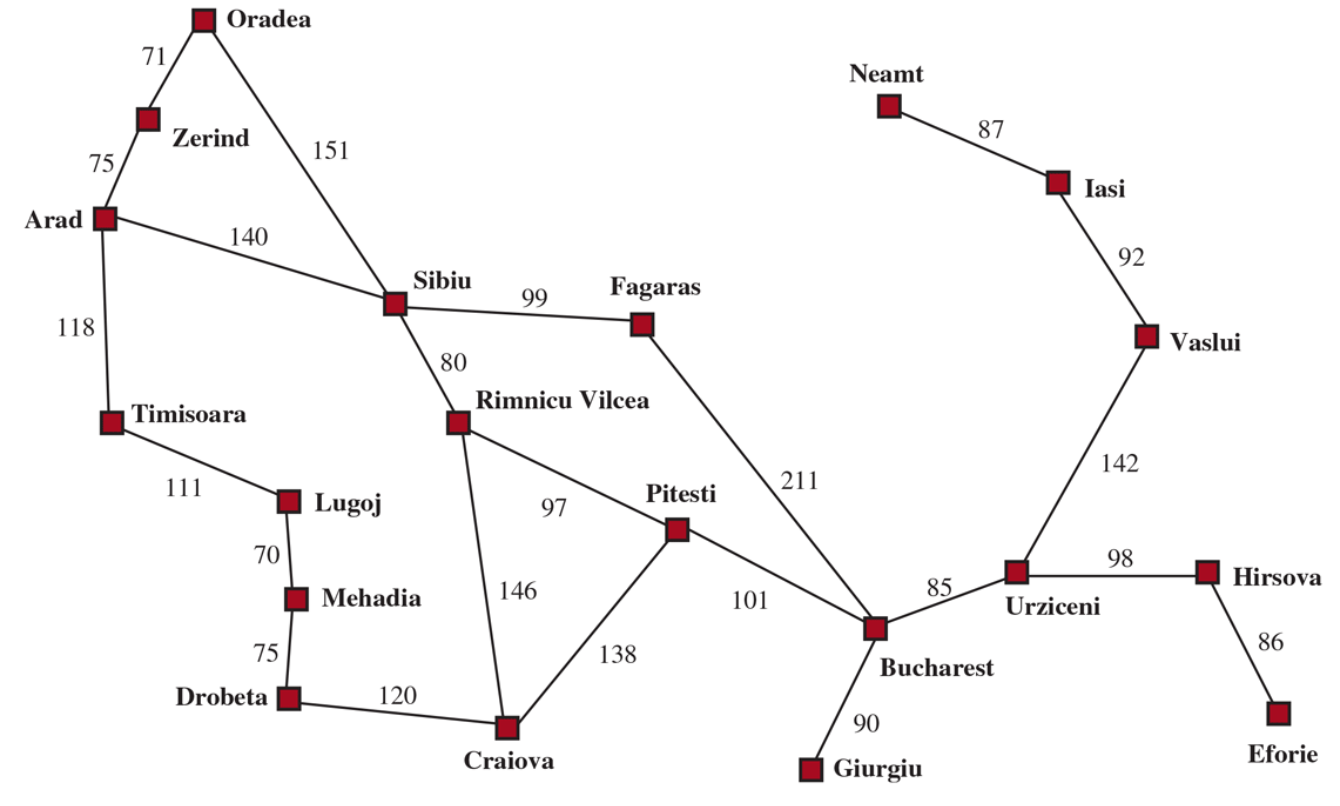

In [ ]:

"""1. Construa o grafo inteiro""" 

nodes = [
  'Oradea',
  'Zerind',
  'Arad',
  'Timisoara',
  'Lugoj',
  'Mehadia',
  'Drobeta',
  'Craiova',
  'Rimnicu Vilcea',
  'Sibiu', 
  'Fagaras',
  'Pitesti',
  'Bucharest',
  'Giurgiu',
  'Urziceni',
  'Hirsova',
  'Eforie',
  'Vaslui',
  'Iasi',
  'Neamt'
]

weights = {
  
  'Oradea': {
    'Zerind' : 71,
    'Sibiu' : 151
    },
  
  'Zerind': {
     'Oradea': 71,
     'Arad' : 75
    },

  'Arad' : {
      'Zerind': 75,
      'Sibiu': 140,
      'Timisoara' : 118
    },

  'Timisoara' :{
     'Arad' : 118, 
     'Lugoj' : 111 
    },

  'Lugoj' : {
      'Timisoara' : 111,
      'Mehadia'  : 70
    },

  'Mehadia' : {
      'Lugoj' : 70,
      'Drobeta' : 75 
    },

  'Drobeta' :{
       'Mehadia' : 75,
       'Craiova' : 120
    },

  'Craiova' : {
       'Drobeta' : 120,
       'Rimnicu Vilcea': 146,
       'Pitesti': 138
    },

  'Rimnicu Vilcea':{
      'Craiova' : 146,
      'Pitesti': 97,
      'Sibiu': 80
   },

  'Sibiu': {
    'Fagaras': 99, 
    'Rimnicu Vilcea': 80,
    'Arad' : 140,
    'Oradea': 151
    },

  'Fagaras': {
    'Bucharest': 211,
    'Sibiu' : 99
  },
 
  'Pitesti': {
    'Bucharest': 101,
    'Rimnicu Vilcea': 97,
    'Craiova': 138

  },

  'Bucharest': {
      'Pitesti': 101,
      'Fagaras': 211,
      'Giurgiu': 90,
      'Urziceni': 85
  },

  'Giurgiu':{ 
      'Bucharest': 90,
  },

  'Urziceni': {
      'Bucharest': 85,
      'Hirsova': 98,
      'Vaslui': 142
  },

  'Hirsova': {
      'Urziceni': 98,
      'Eforie' : 86
  },

  'Eforie' : {
      'Hirsova': 86
  },

  'Vaslui': {
      'Urziceni': 142,
      'Iasi' : 92
  },

  'Iasi' : {
      'Vaslui': 92,
      'Neamt' : 87
  },

  'Neamt' : {
      'Iasi' : 87
  }
}


graph = nx.Graph()
for n in nodes:
  graph.add_node(n)

for u in weights:
  for v in weights[u]:
    graph.add_edge(u, v, weight=weights[u][v], length = 20)



## 1.3 Visualização do Grafo

1. Encontre bons parâmetros para visualizar o grafo
  - figsize
  - seed
  - interations  
  - node_size 
  - font_size 

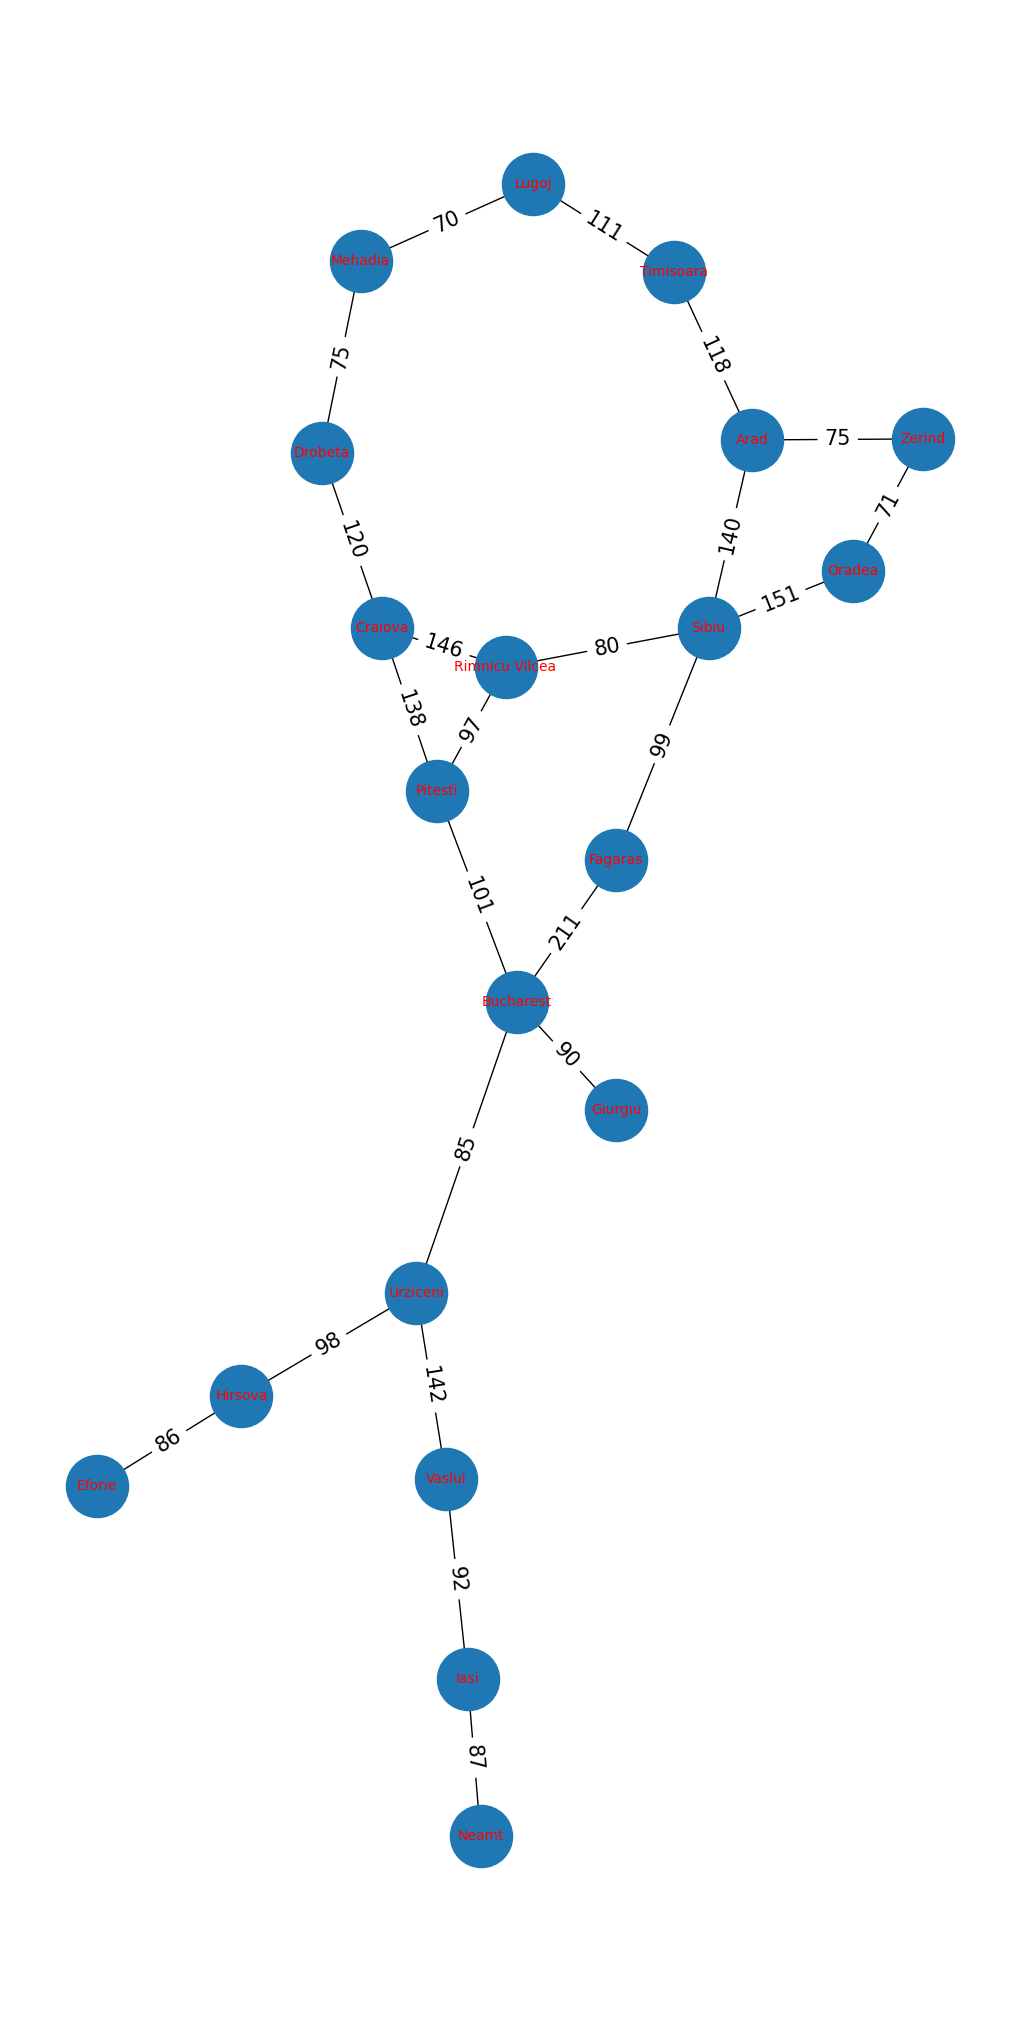

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(10, 20), dpi=100)

pos = nx.spring_layout(graph, k=1, iterations=200,seed=1000)
pos = nx.rescale_layout_dict(pos, scale=400)

nx.draw(graph,
        with_labels=True,
        node_size=2000,
        font_color='red',
        font_size=10,
        pos=pos
        )


edge_labels = dict([((n1, n2), d['weight']) for n1, n2, d in graph.edges(data=True)])
nx.draw_networkx_edge_labels(graph, 
                             pos, 
                             font_size=15,
                             edge_labels=edge_labels)
plt.show()

## 1.3 Busca da Solução Ótima

1. Inicie a busca a partir de `Arad` 

In [ ]:
start_node = 'Vaslui'

visited_nodes = [start_node]
unvisited_nodes = nodes.copy()
unvisited_nodes.remove(start_node)

inital_state = RomaniaState(visited_nodes=visited_nodes,
                     unvisited_nodes=unvisited_nodes)
cost = 0

node = Node(state=inital_state, parent=None, action=None, path_cost=cost)
problem = RomaniaProblem(initial_node=node, graph=graph)

node = best_first_search(problem=problem)

print(f'cost: {node.path_cost} \n solution: {node.state.visited_nodes}')


cost: 227 
 solution: ['Vaslui', 'Urziceni', 'Bucharest']


## 2. Problema do Caixeiro Viajante

## 2.1 Implementação

1. Implemente a verificação de igualdade entre estados em `def __eq__(self, other)
2. Implemente o cáculo do custo em `def action_cost(self, source: State, action: Node, target: State)`
3. Implemente a geração de ações em `def actions(self, state : Node)`
4. Implemente a verificação do estado final em `def is_goal(self, current_state: State)`

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
import numpy as np
from queue import PriorityQueue
import networkx as nx
import tsplib95
import random

@dataclass
class TSPState(State):
    visited_nodes: list
    unvisited_nodes: list

    def __eq__(self, other):
        if not isinstance(other, State):
            return NotImplemented
        """1. Implemente a verificação de igualdade entre estados em `def __eq__(self, other)"""
        return self.visited_nodes == other.visited_nodes

    def __hash__(self):
        return hash(str(self.visited_nodes))

    def __str__(self) -> str:
        return str(self.visited_nodes)

@dataclass
class TSPProblem(Problem):
    graph: nx.Graph

    def action_cost(self, source: State, action: Node, target: State):
      cost = 0
      if len(source.visited_nodes) > 0:
        cost = float("inf")
        source_last_id = source.visited_nodes[-1]
        target_last_id = target.visited_nodes[-1]
        if self.graph.has_edge(source_last_id, target_last_id):
          """2. Implemente o cáculo do custo em `def action_cost(self, source: State, action: Node, target: State)"""
          cost = self.graph.get_edge_data(source_last_id, target_last_id)['weight']
      return cost

    def actions(self, state : Node):
      """3. Implemente a geração de ações em `def actions(self, state : Node)`"""
      if len(state.unvisited_nodes) == 0:
        next_node = TSPState(
            visited_nodes = state.visited_nodes + [state.visited_nodes[0]], unvisited_nodes=[]
            )
        yield next_node

      for node_id in random.sample(state.unvisited_nodes, len(state.unvisited_nodes)):
          unvisited_nodes = list(state.unvisited_nodes)
          unvisited_nodes.remove(node_id)
          next_node = TSPState(visited_nodes=state.visited_nodes + [node_id], unvisited_nodes=unvisited_nodes)
          yield next_node
  
    def is_goal(self, current_state: State):
      """4. Implemente a verificação do estado final em `def is_goal(self, current_state: State)`"""
      return len(current_state.unvisited_nodes) == 0 and current_state.visited_nodes[0] == current_state.visited_nodes[-1]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2.2 Construção do Grafo
1. Importe o arquivo `att48.tsp` no colab

In [ ]:
#tsp_problem_name = "att48"
tsp_problem_name = "/content/drive/MyDrive/Colab Notebooks/att48"
tsp_problem = tsplib95.load(f'{tsp_problem_name}.tsp')
#tsp_problem = tsplib95.load(f'/content/drive/MyDrive/Colab Notebooks/att48.tsp')
tsp_graph = tsp_problem.get_graph()

## 2.3 Visualização do Grafo
1. Encontre bons parâmetros para visualizar o grafo
  - figsize
  - seed
  - interations  
  - node_size 
  - font_size 

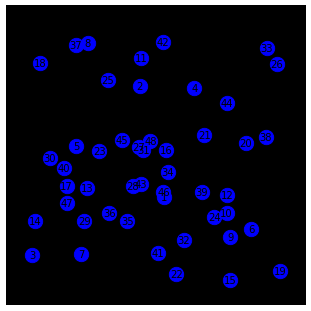

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(5, 5), dpi=60)

pos = nx.spring_layout(tsp_graph, iterations=1, seed=100)

weights = nx.get_edge_attributes(tsp_graph,'weight').values()

scale = 1
weights = [w/scale for w in weights]
nx.draw(tsp_graph, pos, 
        width=list(weights),
        with_labels=True,
        node_color='blue')

plt.show()

## 3.3 Busca da Solução Ótima

1. Qual o papel da variável `nodes_visited` ?
2. O que acontece se aumentarmos o valor da variável `nodes_visited` para 41, 42, ... ?
3. O que acontece se diminuirmos o valor da variável `nodes_visited` para 39, 38, ... ?
4. O que faz o código a seguir ?

```python 
cost = 0
for i in range(len(visited_nodes)-1):
    cost += tsp_graph.get_edge_data(visited_nodes[i], visited_nodes[i+1])['weight']
```

In [ ]:
solution = tsplib95.load(f'{tsp_problem_name}.opt.tour')
optimum_tour = solution.tours[0]
print(f'optimum tour: {optimum_tour}')


optimum tour: [1, 8, 38, 31, 44, 18, 7, 28, 6, 37, 19, 27, 17, 43, 30, 36, 46, 33, 20, 47, 21, 32, 39, 48, 5, 42, 24, 10, 45, 35, 4, 26, 2, 29, 34, 41, 16, 22, 3, 23, 14, 25, 13, 11, 12, 15, 40, 9]


In [ ]:
"""
1. Qual o papel da variável `nodes_visited` ?
2. O que acontece se aumentarmos o valor da variável `nodes_visited` para 41, 42, ... ?
3. O que acontece se diminuirmos o valor da variável `nodes_visited` para 39, 38, ... ?
"""
nodes_visited = 25

visited_nodes = optimum_tour[0:nodes_visited]
][]´ç
unvisited_nodes = optimum_tour[nodes_visited:]

inital_state = TSPState(visited_nodes=visited_nodes,
                     unvisited_nodes=unvisited_nodes)
"""4. O que faz o código a seguir ?"""
cost = 0
for i in range(len(visited_nodes)-1):
    cost += tsp_graph.get_edge_data(visited_nodes[i], visited_nodes[i+1])['weight']

node = Node(state=inital_state, parent=None, action=None, path_cost=cost)
problem = TSPProblem(initial_node=node, graph=tsp_graph)

node = best_first_search(problem=problem)


print(f'cost: {node.path_cost} \n solution: {node.state.visited_nodes}')